In [1]:
import h5py
import numpy as np
from scipy import signal, ndimage
import sys
import os
sys.path.append(os.path.abspath("../src"))

from alignment import CrossCorrelationAlignment, TomoConsistencyAlignment, TomoConsistencyConfig, VerticalAlignment, VerticalAlignmentConfig
import utilities as utils

TomoPy links to compiled components which are installed separately and loaded using ctypes.util.find_library(). A required library, tomo-recon, was not found.
No module named 'recast_tomo'


#### Load data

In [2]:
# folder = '/mnt/share/ALC_ptychography_alignment/Experimental/connor_wright'
# folder = '/dls/i13-1/data/2025/cm40629-5/processing/ptycho-tomo_alignment/i14_example_dataset/'
folder = '/dls/i13-1/data/2025/cm40629-5/processing/ptycho-tomo_alignment/example_dataset/'
file = folder + '/example_data.h5' #'/scan_275019_275199_tomo_complex.nxs'
# img, theta, _ = utils.io_tools.load_data(file, data_key= '/entry1/data', angle_key = '/entry1/rotation_angle')
img, theta, _ = utils.io_tools.load_data(file, data_key='stack_object', angle_key = 'theta')
# img = img.transpose((1,2,0)) # transpose to shape [Ny, Nx, Nangles]

raw data shape: (284, 335, 316)
projections shape: (284, 335, 316)
angles shape: (316,)


Here we remove one duplicate angle, this should be replaced with code to automatically find the angles to remove

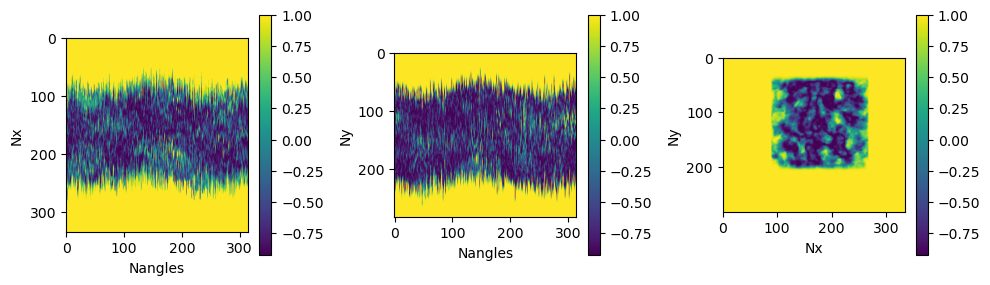

In [3]:
# img = img[:,:,:]
# theta = theta[:]
img = img[:,:,1:]
theta = theta[1:]
utils.display_tools.plot_3axes(img.real, array_name='', data_order=['Ny', 'Nx','Nangles'])


Next choose a range to crop in vertical (Ny) and horizontal (Nx)

In [4]:
[Ny, Nx, Nangles] = img.shape
Ny_start = 10
Ny_stop = Ny-Ny_start

Nx_start = 10
Nx_stop = Nx-Nx_start

utils.display_tools.plot_crop(img.real, Nx_start, Nx_stop, Ny_start, Ny_stop, Nangles)

interactive(children=(IntSlider(value=157, description='slice_idx', max=314), Output()), _dom_classes=('widget…

#### Quick cross-correlation alignment

This could be replaced with a different method

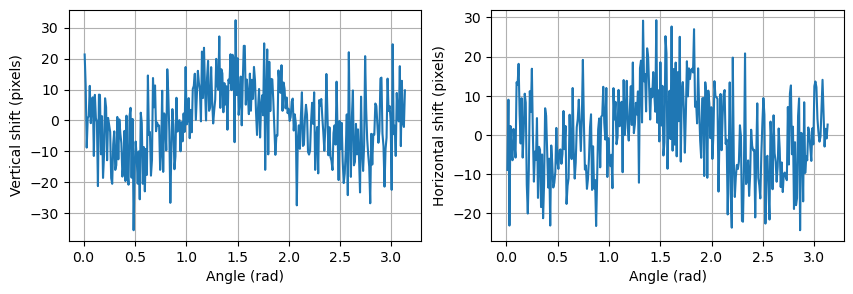

In [5]:
xcorr = CrossCorrelationAlignment()
shift_correlation = xcorr.run_alignment(img[Ny_start:Ny_stop,Nx_start:Nx_stop,:], theta)

If we're satisfied with the alignment save the calculated values to the total_shifts array. 

We can choose to apply the shifts we found to only horizontal OR both

In [6]:
shift_total = np.zeros((Nangles,2))

shift_total[:,0] = shift_total[:,0] + shift_correlation[:,0] # only apply horizontal
# shift_total = shift_total + shift_correlation # apply both

#### Vertical alignment

First we do a 2D phase unwrapping - this requires complex data so if we do not have complex data, skip the unwrapping step and try the vertical alignment directly on the image

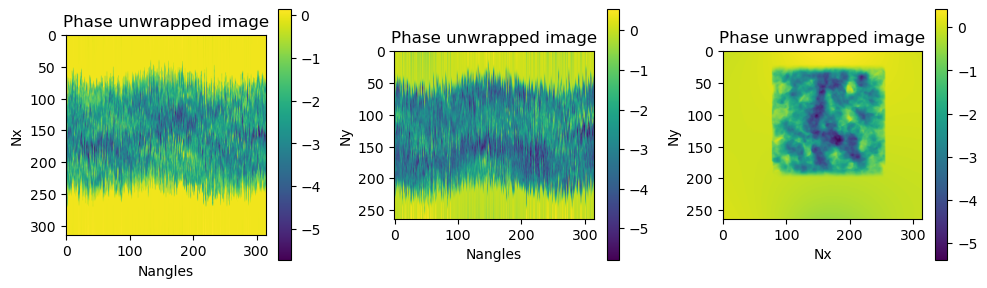

In [7]:
phase, residuals = utils.phase_tools.unwrap2D_fft2(img[Ny_start:Ny_stop,Nx_start:Nx_stop,:], empty_region=(20,20))
phase=phase.real

utils.display_tools.plot_3axes(phase, 'Phase unwrapped image', ['Ny','Nx','Nangles'])

Run the vertical mass alignment code. It first runs a quick cross-correlation estimate and then uses vertical mass fluctuation to iteratively improve on the result.
Here we run the code with default config values but they can be edited by redifining any variable as shown below.

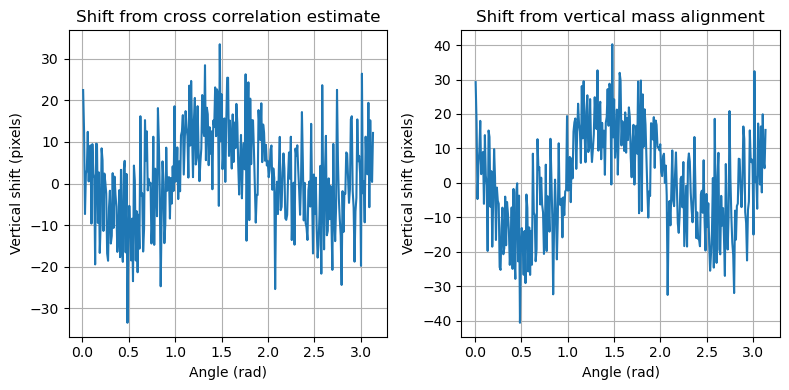

In [8]:
config = VerticalAlignmentConfig(
    data_filter = 0.01,
    iterations = 1000) # over-ride defaults here if needed
va = VerticalAlignment(config)
shift_vertical = va.run_alignment(phase, residuals, theta)

If we're satisfied with the alignment, save the calculated values to the total_shifts array. 

Here we only apply shifts to the vertical

In [9]:
shift_total[:,1] = shift_total[:,1] + shift_vertical

In [10]:
# Debug only - comparison with matlab
# shifttt = np.zeros((180,2))
# horiz_shifts = "34	53	71	53	46	60	49	59	94	53	49	42	16	10	2	-1	3	7	-7	-10	-12	16	-10	-10	15	23	12	16	-1	7	1	20	5	-15	-13	-20	-43	-32	-31	-22	-28	-41	-30	-17	-10	-14	5	16	1	8	-3	11	9	2	-10	-14	-4	1	-3	-12	0	2	4	23	-4	17	17	15	-3	16	13	-8	1	20	24	12	-4	12	21	26	26	17	39	37	22	10	33	38	37	25	28	25	34	37	36	25	20	19	14	21	6	29	11	5	12	18	23	22	4	14	5	2	-7	-17	4	10	5	-23	-7	-16	-5	-14	-15	-12	-30	-2	8	37	9	-13	-25	-1	-20	-38	-12	-42	-38	-30	-14	-50	-29	-18	-39	-16	-18	-24	-30	-17	-9	-5	-18	-8	-18	-21	-27	-14	-34	-17	-8	-1	11	15	33	50	45	32	55	43	52	71	65	55	78	82	86	81	88	87	102	99"
# verti_shifts = "15.413752	18.869938	17.952105	15.048748	15.317489	16.457272	12.412716	12.346809	10.830973	11.337815	10.017136	5.8283844	10.083050	5.8169851	6.0416551	4.2934666	5.6583614	5.9371600	4.0354943	5.7538233	3.3005543	3.7650852	5.2703390	1.8591213	5.4564781	2.8896022	2.1997428	-0.17467356	-1.9699535	0.87871838	-3.2357435	0.76823330	-2.5602198	-2.1836128	-1.9600611	-4.5140209	-0.36251450	-3.0791235	-4.6122513	-9.9342089	-7.4991922	-5.3061371	-6.2287035	-5.0426693	-5.3855629	-7.9935055	-7.9635601	-7.0324230	-7.1765413	-6.2677298	-8.1166430	-9.2110443	-12.414388	-11.159865	-10.753753	-8.2610178	-13.170260	-11.250447	-10.745543	-14.356794	-11.571807	-11.877501	-12.783373	-13.843271	-14.373517	-10.941634	-14.464982	-12.502694	-13.538865	-12.422956	-11.257554	-13.799178	-10.734569	-10.189597	-12.750818	-9.7716684	-11.705909	-9.7415876	-11.212492	-10.909909	-12.516102	-14.289781	-8.9605494	-10.871581	-12.549095	-11.684525	-11.340709	-8.3016386	-9.5872774	-9.6175232	-4.7576141	-8.8119392	-7.6817207	-5.5180302	-4.1780596	-6.6357822	-6.3888206	-9.7493811	-7.3984365	-8.9965677	-4.9184933	-6.0479937	-6.1219254	-8.5863094	-4.4894323	-6.1594181	-5.1547985	-1.6491451	-2.7983265	-4.8097448	-5.3291540	0.41888046	-2.4759121	-4.6141396	-0.88960218	2.6166501	-2.0870996	-0.31212139	-2.6427526	-2.8247013	-1.2003055	-1.7152777	0.36425114	2.0175438	4.4538631	5.2944336	5.1687856	6.4964113	7.2222686	6.8367939	8.5167551	4.5047450	6.3769894	6.7455845	6.9169655	10.386265	8.1206379	8.1449308	10.452344	11.728489	9.8030329	10.273876	13.346823	12.488131	9.9812059	10.827835	15.084057	11.828949	19.741692	16.388168	16.768448	17.337341	15.531812	16.133751	15.302582	18.366550	17.546852	22.554668	17.627645	20.540474	22.700542	20.932266	21.294281	23.177410	25.027546	26.459126	23.972595	27.682163	26.186676	22.967850	26.703648	26.649876	28.135220	29.545984	28.637554	31.443890	31.050766	25.562595	29.057617	29.617386"
# shifttt[:,0] = np.fromstring(horiz_shifts, sep=' ')
# shifttt[:,1] = np.fromstring(verti_shifts, sep=' ')

# import matplotlib.pyplot as plt
# plt.figure(figsize=[10,3])
# plt.subplot(121),plt.plot(theta, shift_total[:,1], label='Python')
# plt.subplot(121),plt.plot(theta, shifttt[:,1], '--', label='MATLAB code') 
# plt.ylabel('Vertical shift (pixels)'), plt.xlabel('Angle (rad)')
# plt.subplot(122),plt.plot(theta, shift_total[:,0], label='Python')
# plt.subplot(122),plt.plot(theta, shifttt[:,0], '--', label='MATLAB code')
# plt.ylabel('Horizontal shift (pixels)'), plt.xlabel('Angle (rad)')
# plt.legend()

Apply shift total to the original image

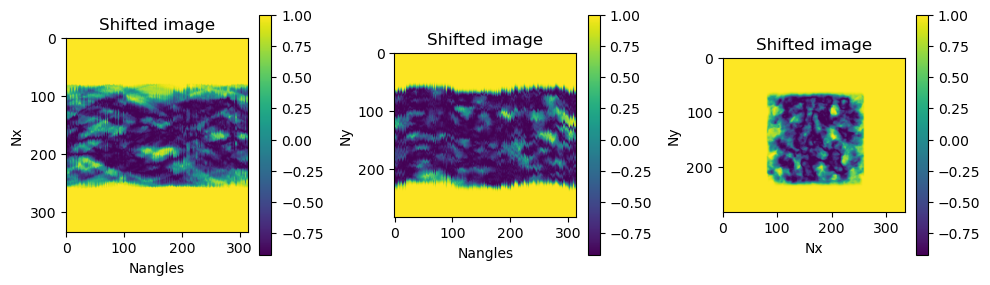

In [11]:
for m in range(shift_total.shape[0]):
    img[:,:,m] = np.roll(img[:,:,m],(int(shift_total[m,0]), int(shift_total[m,1])),axis=(1,0)) 
utils.display_tools.plot_3axes(img.real, 'Shifted image', ['Ny', 'Nx', 'Nangles'])

#### Tomoconsistency alignment

First get the phase gradient and calculate weights

In [12]:
# get the phase gradient
img_grad = utils.phase_tools.get_phase_gradient_1D(img, ax=1)[Ny_start:Ny_stop,Nx_start:Nx_stop,:] # apply on the full image then re-crop
[Ny, Nx, Nangles] = img_grad.shape

high_pass_filter = 0.01
# include the effect of high pass filter into the weights 
size = np.maximum(3, int(np.ceil(high_pass_filter * Nx)))
gauss_window = signal.windows.gaussian(size, std = size/6)
hanning_window = signal.windows.hann(3)
ker = gauss_window.reshape(-1,1) * hanning_window

# relevance weights -> remove effect of potential residues / phase jumps 
ker2 = ker[np.newaxis,:,:]
convolution_result = ndimage.convolve((np.abs(img_grad) > 2).astype(np.float32), ker2.astype(np.float32), mode = 'constant', cval = 0.0)
weights_find_shift = np.maximum(0,1-convolution_result)

We can further reduce the vertical range here if needed

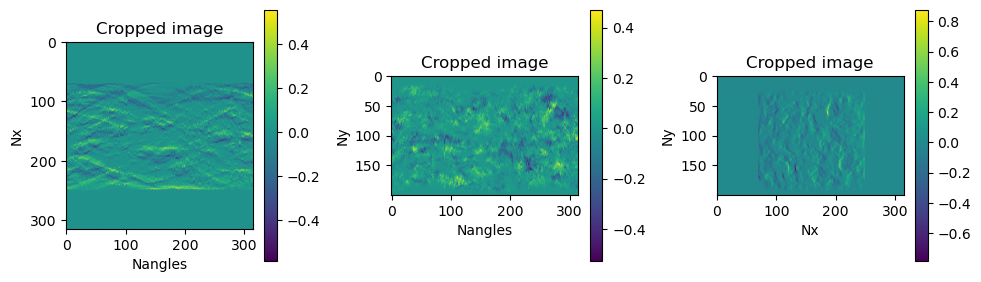

In [13]:
vert_range = (31, Ny-33)

utils.display_tools.plot_3axes(img_grad.real[vert_range[0]:vert_range[1],:,:], 'Cropped image', ['Ny', 'Nx', 'Nangles'])

ROI = (
    slice(int(vert_range[0]), int(vert_range[1])),
    slice(None)
)

Setup the alignment code with default values

In [14]:
config = TomoConsistencyConfig(
    max_iterations = 200,
    step_relaxation = 0.5,
    high_pass_filter = 0.01,
    min_step_size = 0.01,
    unwrap_data_method = 'fft_1d',
    plot_interactive = True,
    center_reconstruction = True,
    apply_mask = False,
    momentum_acceleration = True,
    align_horizontal = True,
    align_vertical = False,
    apply_positivity = True)

aligner = TomoConsistencyAlignment(config)


Run the TomoConsistency code with different binning levels

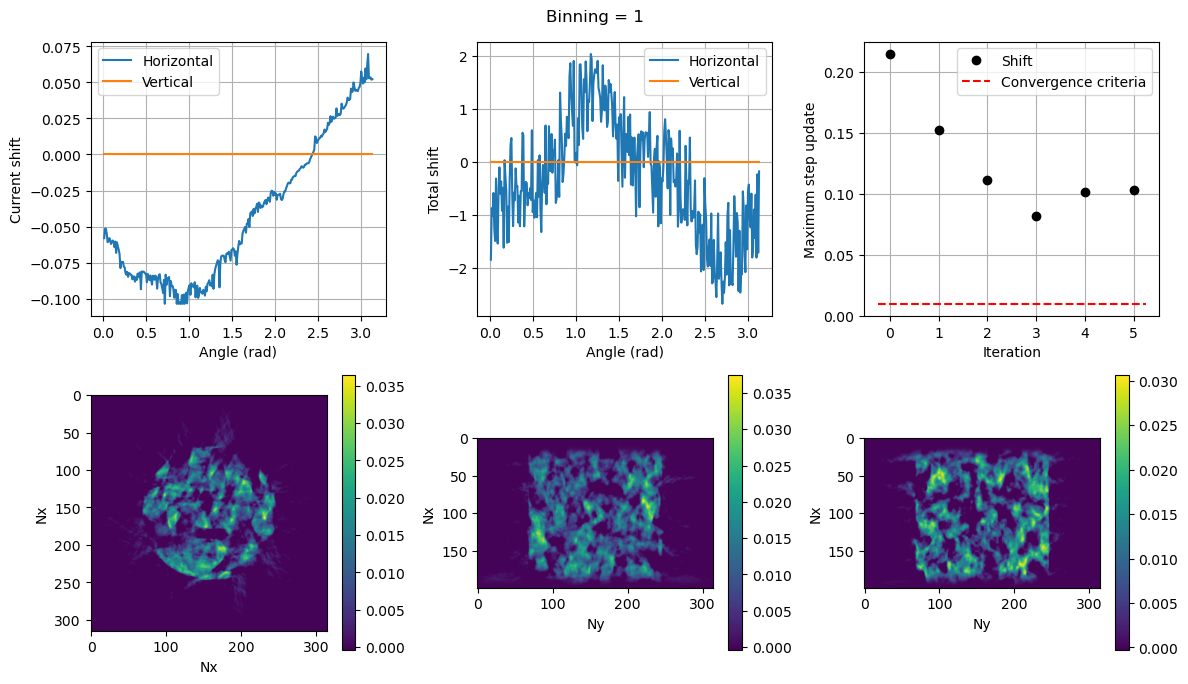

Total time: 1.56 minutesconds


In [15]:
import time
t0 = time.time()

# Loop over different binning levels
bin_levels = [ 4, 2, 1] 

shift_tomoconsistency = np.zeros((Nangles,2))
for binning in bin_levels:

    # Apply ROI and binning
    sinogram = utils.shift_tools.imshift_generic(img_grad, shift=np.zeros((Nangles,2)), Npix = None, affine_matrix = None, smooth = 5, 
                                        ROI = ROI, downsample = binning, interp_method = 'fft', interp_sign = 1)
    

    weights_find_shift = np.maximum(0,1-convolution_result)
    weights_find_shift = utils.shift_tools.imshift_generic(weights_find_shift, shift=np.zeros((Nangles,2)), Npix = None, affine_matrix = None, smooth = 0, 
                                        ROI = ROI, downsample = binning, interp_method = 'linear', interp_sign = 1)
    
    shift_tomoconsistency, _, rec, _ = aligner.run_alignment(sinogram, theta, weights_find_shift, shift_tomoconsistency, binning)

print(f'\rTotal time: {(time.time() - t0)/60:.2f} minutes')

In [16]:
shift_total[:,0] = shift_total[:,0] + shift_tomoconsistency[:,0] # only apply horizontal
# shift_total = shift_total + shift_tomoconsistency # apply both

#### Perform the reconstruction ourselves

We can plot the reconstruction again

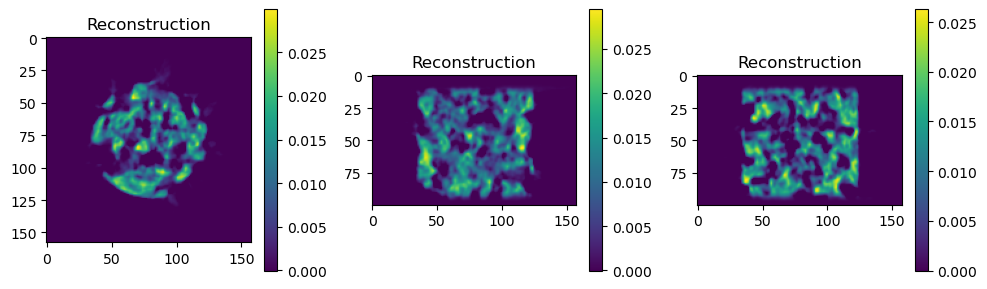

In [17]:
utils.display_tools.plot_3axes(rec, 'Reconstruction')

Or run the reconstruction directly using the shifts we found from the alignment:
- Apply shifts and whatever binning or ROI we want, or just reconstruct everything
- Apply phase unwrapping
- Run the reconstruction
- Apply a circular mask and remove negative values

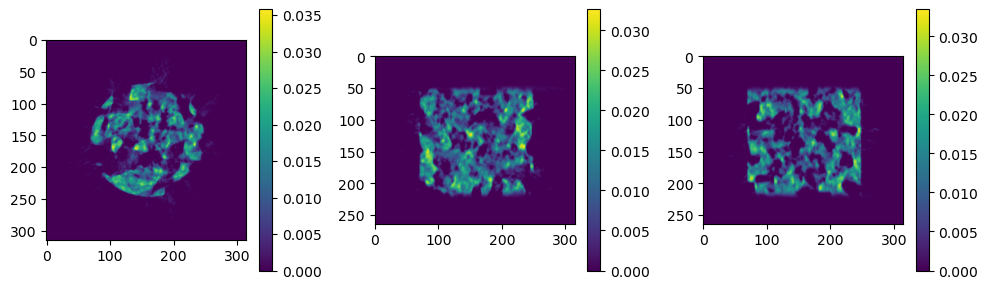

In [18]:
# bin or apply ROI or use full data
# img_grad = utils.phase.get_phase_gradient_1D(img, ax=1) # re-run phase gradient calculation if you want to skip the initial cropping as well 

sinogram = utils.shift_tools.imshift_generic(img_grad, shift=shift_tomoconsistency, Npix = None, affine_matrix = None, smooth = 5, 
                                        ROI = None, downsample = 1, interp_method = 'fft', interp_sign = 1) # can include ROI here too
                                        
import astra

# transpose for astra
sinogram = sinogram.transpose((0, 2, 1))
[Ny, Nangles, Nx] = sinogram.shape

# apply phase unwrapping
phase = -utils.phase_tools.unwrap2D_fft(sinogram, axis=2, boundary=None)[0]

# run reconstruction
dtheta = (theta[-1] - theta[0]) / (len(theta) - 1) if len(theta) > 1 else 1.0
weights_fbp = np.full(len(theta), dtheta, dtype=np.float32)

vol_geom, proj_geom = utils.recon_tools.init_astra(Nx, Ny, theta)
rec = utils.recon_tools.FBP_astra(phase, vol_geom, proj_geom, weights_fbp)

# apply circular mask
rec = utils.recon_tools.apply_circular_mask(rec, 0.9)

# remove negative values
rec = np.maximum(0, rec)

utils.display_tools.plot_3axes(rec)

#### Fourier ring correlation

Get two reconstructions for the Fourier ring correlation. Split data and run reconstruction

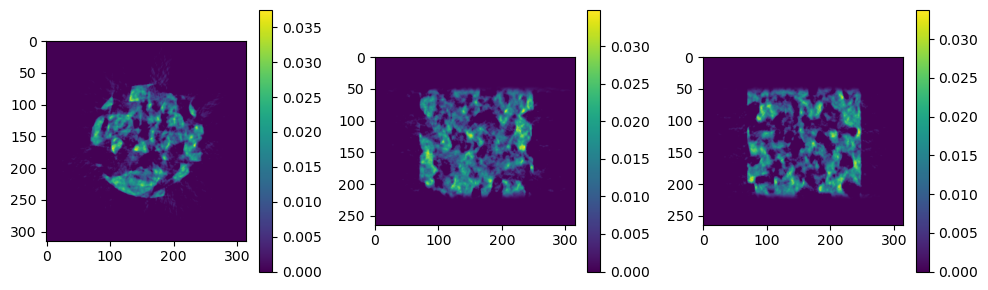

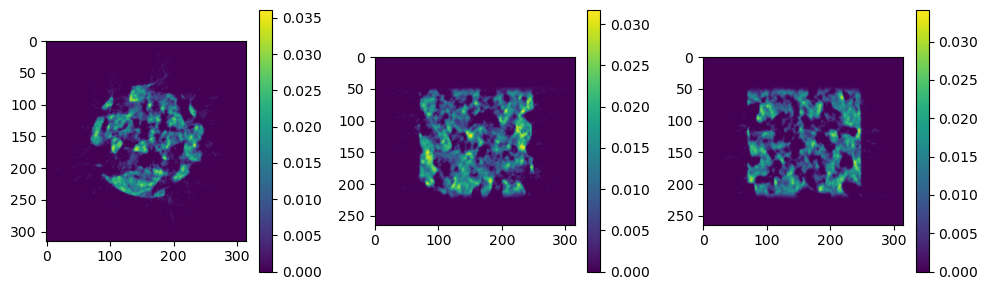

In [19]:
rec_list = []
for i in range(2):
    sinogram_half = phase[:, i::2, :]
    theta_half = theta[i::2]

    [Ny, Nangles, Nx] = sinogram_half.shape

    # run reconstruction
    dtheta = (theta_half[-1] - theta_half[0]) / (len(theta_half) - 1) if len(theta_half) > 1 else 1.0
    weights_fbp = np.full(len(theta_half), dtheta, dtype=np.float32)

    Nz = Nx
    vol_geom = astra.create_vol_geom(Nx, Nz, Ny)

    # Projection geometry (3D parallel beam)
    proj_geom = astra.create_proj_geom(
        'parallel3d',
        1,  # detector pixel size in x
        1,  # detector pixel size in y   
        Ny,          
        Nx,          
        theta_half
    )

    rec = utils.recon_tools.FBP_astra(sinogram_half, vol_geom, proj_geom, weights_fbp)

    # apply circular mask
    rec = utils.recon_tools.apply_circular_mask(rec, 0.9)

    # remove negative values
    rec = np.maximum(0, rec)

    rec_list.append(rec)
utils.display_tools.plot_3axes(rec_list[0])
utils.display_tools.plot_3axes(rec_list[1])

Run 2D Fourier ring correlation

Spatial resolution is roughly  60.19108280254776  -  66.54929577464787  nm.


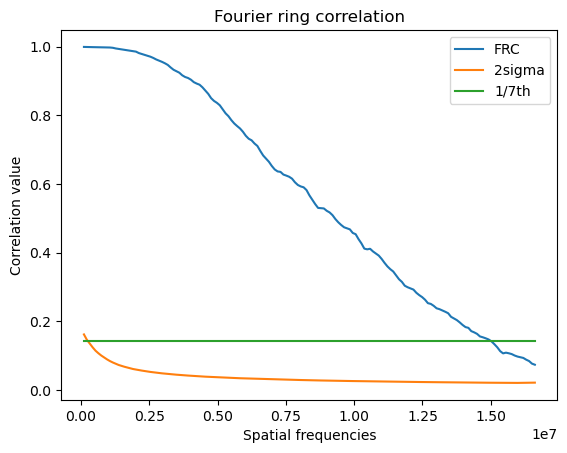

In [20]:
utils.quality_metrics.fourier_ring_correlation(rec_list[0][rec_list[0].shape[0]//2,:,:], rec_list[1][rec_list[1].shape[0]//2,:,:])

#### Save

Uncomment below to save the shifts as csv and the reconstruction as a tiff stack

In [ ]:
# np.savetxt('shift_total.csv', shift_total, delimiter=',', header='horizontal,vertical', comments='')

In [ ]:
# save_dir = 'reconstruction'
# os.makedirs(save_dir, exist_ok=True)

# for i in range(rec.shape[0]):
#     tifffile.imwrite(os.path.join(save_dir, f'slice_{i:04d}.tif'), rec[i])